In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:


df = pd.read_csv(
    "accepted_2007_to_2018Q4.csv",
    # usecols=cols_to_use,
    low_memory=False
)

In [4]:
df['target'] = df['loan_status'].apply(
    lambda x: 1 if x in ['Charged Off', 'Late (31-120 days)', 'Late (16-30 days)', 'Default']
    else 0
)
print(df['target'].value_counts())
print("Default rate: ", round(df['target'].mean()*100, 2), "%")

target
0    1966286
1     294415
Name: count, dtype: int64
Default rate:  13.02 %


In [5]:
# Drop identifier columns
df.drop(columns=['id', 'member_id'], inplace=True)

# Drop post-default leakage columns
leakage_cols = [    'loan_status',
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',
    'last_credit_pull_d', 'debt_settlement_flag',
    'last_fico_range_low', 'last_fico_range_high',
    'fico_range_low', 'fico_range_high',
    'hardship_flag', 'hardship_status', 'hardship_amount',
    'hardship_reason', 'hardship_start_date', 'hardship_end_date',
    'disbursement_method', 'funded_amnt_inv',
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term',
    'id', 'member_id', 'url', 'desc', 'title',
    'zip_code', 'policy_code',
    'pymnt_plan','grade', 'sub_grade']
df.drop(columns=[c for c in leakage_cols if c in df.columns], inplace=True)
print("Shape after dropping:", df.shape)

Shape after dropping: (2260701, 110)


In [6]:
df_sample = df.groupby('target', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 100000), random_state=42)
)
print("Sample Shape: ", df_sample.shape)
print("target balance in sample:", df_sample['target'].value_counts())

Sample Shape:  (200000, 110)
target balance in sample: target
0    100000
1    100000
Name: count, dtype: int64


C:\Users\LOQ\AppData\Local\Temp\ipykernel_29648\1248965101.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('target', group_keys=False).apply(


In [7]:
missing = df.isnull().mean().sort_values(ascending=False)*100
high_missing = missing[missing > 40]
print(f"Columns with > 40% missing: {len(high_missing)}")
print(high_missing)

# drop
df.drop(columns=high_missing.index, inplace=True)
print("Shape after droping missing columns:", df.shape)

Columns with > 40% missing: 33
orig_projected_additional_accrued_interest    99.617331
hardship_dpd                                  99.517097
deferral_term                                 99.517097
hardship_type                                 99.517097
hardship_loan_status                          99.517097
hardship_length                               99.517097
payment_plan_start_date                       99.517097
hardship_payoff_balance_amount                99.517097
hardship_last_payment_amount                  99.517097
debt_settlement_flag_date                     98.485160
sec_app_mths_since_last_major_derog           98.410139
sec_app_revol_util                            95.303050
revol_bal_joint                               95.221836
sec_app_mort_acc                              95.221792
sec_app_open_acc                              95.221792
sec_app_fico_range_low                        95.221792
sec_app_fico_range_high                       95.221792
sec_app_inq_last_

In [8]:
df['int_rate']=df['int_rate'].astype(float)
df['revol_util']=df['revol_util'].astype(float)
df['term']=df['term'].str.extract('(\d+)').astype(float)

emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
}
df['emp_length'] = df['emp_length'].map(emp_map)

df['earliest_cr_line'] = pd.to_datetime(
    df['earliest_cr_line'], format='%b-%Y', errors='coerce'
).dt.year

print("Types fixed.")

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\LOQ\AppData\Local\Temp\ipykernel_29648\1112112577.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['term']=df['term'].str.extract('(\d+)').astype(float)


Types fixed.


In [9]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

num_cols = [c for c in num_cols if c!='target']

for col in num_cols:
  median_val = df[col].median()
  df[col].fillna(median_val, inplace=True)

for col in cat_cols:
  mode_val = df[col].mode()
  df[col].fillna(mode_val, inplace=True)

print("Remaining nulls:",df.isnull().sum().sum())

C:\Users\LOQ\AppData\Local\Temp\ipykernel_29648\791692060.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
C:\Users\LOQ\AppData\Local\Temp\ipykernel_29648\791692060.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doi

Remaining nulls: 167233


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
  df[col] = le.fit_transform(df[col].astype(str))

In [11]:
# Loan-to-income ratio: how large is the loan relative to their income?
df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)

# Installment burden: monthly payment as % of monthly income
df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12 + 1)

# Credit history length: years between earliest credit line and loan issue
df['issue_year'] = pd.to_datetime(
    df['issue_d'], format='%b-%Y', errors='coerce'
).dt.year
df['credit_history_years'] = df['issue_year'] - df['earliest_cr_line']
df['credit_history_years'] = df['credit_history_years'].clip(lower=0)

# Total credit exposure
df['total_credit_lines'] = df['open_acc'] + df['total_acc']

# Drop helper columns
df.drop(columns=['issue_d', 'issue_year'], inplace=True)

print("New features created.")
print(df[['loan_to_income', 'installment_to_income',
          'credit_history_years', 'total_credit_lines']].describe())

New features created.
       loan_to_income  installment_to_income  credit_history_years  \
count    2.260701e+06           2.260701e+06                   0.0   
mean     1.454496e+01           5.025422e-01                   NaN   
std      6.018587e+02           1.763306e+01                   NaN   
min      1.612903e-04           6.383213e-05                   NaN   
25%      1.249984e-01           4.583904e-02                   NaN   
50%      1.999973e-01           7.151954e-02                   NaN   
75%      2.990450e-01           1.053915e-01                   NaN   
max      4.000000e+04           1.714540e+03                   NaN   

       total_credit_lines  
count        2.260701e+06  
mean         3.577488e+01  
std          1.651070e+01  
min          2.000000e+00  
25%          2.400000e+01  
50%          3.300000e+01  
75%          4.500000e+01  
max          2.540000e+02  


In [12]:
# Cap continuous features at sensible real-world limits
outlier_caps = {
    'dti':            (0, 50),      # debt-to-income: 0–50%
    'revol_util':     (0, 100),     # utilization: 0–100%
    'annual_inc':     (0, 500000),  # income: up to $500k
    'loan_to_income': (0, 10),      # loan can't be 10x income realistically
    'revol_bal':      (0, 200000),  # revolving balance cap
}

for col, (low, high) in outlier_caps.items():
    if col in df.columns:
        before = df[col].max()
        df[col] = df[col].clip(lower=low, upper=high)
        print(f"{col}: capped from {before:.1f} → {high}")

print("\nOutlier capping done.")


# dti min=-1.00 is also wrong — clip to 0
df['dti'] = df['dti'].clip(lower=0)
print("dti negative values fixed.")

dti: capped from 999.0 → 50
revol_util: capped from 892.3 → 100
annual_inc: capped from 110000000.0 → 500000
loan_to_income: capped from 40000.0 → 10
revol_bal: capped from 2904836.0 → 200000

Outlier capping done.
dti negative values fixed.


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = df.select_dtypes(exclude='object')

X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [14]:
from xgboost import XGBClassifier

scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    scale_pos_weight=scale,
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.5,
    eval_metric='auc',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
    verbose=50)

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]



[0]	validation_0-auc:0.70068
[50]	validation_0-auc:0.72171
[100]	validation_0-auc:0.72768
[150]	validation_0-auc:0.73114
[200]	validation_0-auc:0.73419
[250]	validation_0-auc:0.73675
[300]	validation_0-auc:0.73903
[350]	validation_0-auc:0.74061
[400]	validation_0-auc:0.74206
[450]	validation_0-auc:0.74338
[500]	validation_0-auc:0.74464
[550]	validation_0-auc:0.74581
[600]	validation_0-auc:0.74705
[650]	validation_0-auc:0.74808
[700]	validation_0-auc:0.74878
[750]	validation_0-auc:0.74946
[800]	validation_0-auc:0.75023
[850]	validation_0-auc:0.75095
[900]	validation_0-auc:0.75157
[950]	validation_0-auc:0.75216
[999]	validation_0-auc:0.75265


In [15]:
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix)

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))



              precision    recall  f1-score   support

           0       0.94      0.66      0.78    393258
           1       0.24      0.71      0.36     58883

    accuracy                           0.67    452141
   macro avg       0.59      0.69      0.57    452141
weighted avg       0.85      0.67      0.72    452141

AUC: 0.7526491374816346


In [16]:

thresholds = np.arange(0.20, 0.55, 0.05)
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<10} {'F1':<10}")
print("-"*44)

from sklearn.metrics import precision_score, recall_score, f1_score

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f = f1_score(y_test, y_pred_t)
    print(f"{t:<12.2f} {p:<12.3f} {r:<10.3f} {f:<10.3f}")

Threshold    Precision    Recall     F1        
--------------------------------------------
0.20         0.153        0.979      0.265     
0.25         0.163        0.961      0.279     
0.30         0.174        0.934      0.293     
0.35         0.187        0.898      0.309     
0.40         0.201        0.849      0.325     
0.45         0.219        0.786      0.342     
0.50         0.239        0.710      0.358     


In [17]:
# Check 1 — did scale_pos_weight get set?
print("scale_pos_weight:", xgb_model.get_params()['scale_pos_weight'])

# Check 2 — what's your actual imbalance ratio?
print("Class counts:", y_train.value_counts().to_dict())
print("Correct scale_pos_weight should be:", 
      round((y_train == 0).sum() / (y_train == 1).sum(), 2))

# Check 3 — are there data leakage columns still present?
print("\nFeature count:", X_train.shape[1])
print("First 10 features:", list(X_train.columns[:10]))

scale_pos_weight: 6.678616918295603
Class counts: {0: 1573028, 1: 235532}
Correct scale_pos_weight should be: 6.68

Feature count: 79
First 10 features: ['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status']


In [18]:
# Full data audit
print("="*50)
print("1. FEATURE IMPORTANCE - top 20")
print("="*50)
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
print(feat_imp.head(20))

print("\n" + "="*50)
print("2. GRADE DISTRIBUTION vs DEFAULT RATE")
print("="*50)
# print(df.groupby('grade')['target'].agg(['mean','count']))

print("\n" + "="*50)
print("3. KEY FEATURE STATS AFTER CAPPING")
print("="*50)
for col in ['int_rate', 'dti', 'revol_util', 'annual_inc', 'loan_to_income']:
    if col in df.columns:
        print(f"{col}: min={df[col].min():.2f}, max={df[col].max():.2f}, mean={df[col].mean():.2f}")

print("\n" + "="*50)
print("4. TARGET DISTRIBUTION")
print("="*50)
print(df['target'].value_counts())
print("Default rate:", round(df['target'].mean()*100, 2), "%")

print("\n" + "="*50)
print("5. SAMPLE OF RAW DATA")
print("="*50)
print(df[['int_rate', 'dti', 'annual_inc', 'target']].head(10))

1. FEATURE IMPORTANCE - top 20
int_rate                 0.128248
verification_status      0.060128
open_rv_24m              0.060066
acc_open_past_24mths     0.041291
term                     0.041012
open_acc_6m              0.040379
application_type         0.028761
home_ownership           0.028729
all_util                 0.024755
max_bal_bc               0.023388
loan_to_income           0.019758
inq_last_12m             0.017785
earliest_cr_line         0.017699
inq_last_6mths           0.016710
installment_to_income    0.016545
tot_hi_cred_lim          0.016438
mths_since_recent_inq    0.015796
emp_title                0.013608
delinq_2yrs              0.013543
mo_sin_old_rev_tl_op     0.013310
dtype: float32

2. GRADE DISTRIBUTION vs DEFAULT RATE

3. KEY FEATURE STATS AFTER CAPPING
int_rate: min=5.31, max=30.99, mean=13.09
dti: min=0.00, max=50.00, mean=18.53
revol_util: min=0.00, max=100.00, mean=50.33
annual_inc: min=0.00, max=500000.00, mean=77141.29
loan_to_income: min=0.00

In [19]:
key_cols = ['int_rate', 'dti', 'revol_util', 'annual_inc', 
            'open_acc', 'total_acc', 'revol_bal']

for col in key_cols:
    if col in df.columns:
        pct_valid = df[col].notna().mean() * 100
        print(f"{col}: {pct_valid:.1f}% valid, dtype={df[col].dtype}")

int_rate: 100.0% valid, dtype=float64
dti: 100.0% valid, dtype=float64
revol_util: 100.0% valid, dtype=float64
annual_inc: 100.0% valid, dtype=float64
open_acc: 100.0% valid, dtype=float64
total_acc: 100.0% valid, dtype=float64
revol_bal: 100.0% valid, dtype=float64


In [20]:
print(list(X_train.columns))

['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'total_bal_il', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_a

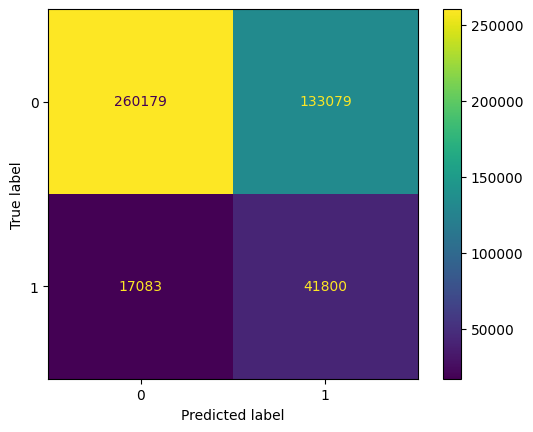

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

int_rate                 0.128248
verification_status      0.060128
open_rv_24m              0.060066
acc_open_past_24mths     0.041291
term                     0.041012
open_acc_6m              0.040379
application_type         0.028761
home_ownership           0.028729
all_util                 0.024755
max_bal_bc               0.023388
loan_to_income           0.019758
inq_last_12m             0.017785
earliest_cr_line         0.017699
inq_last_6mths           0.016710
installment_to_income    0.016545
dtype: float32


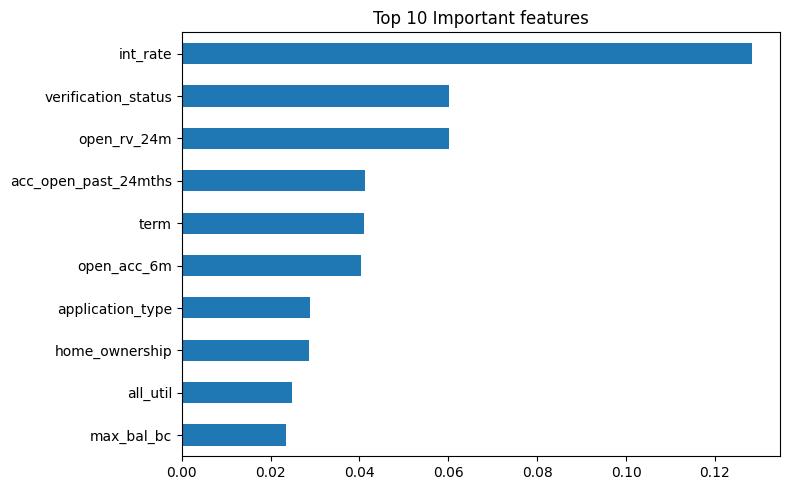

In [22]:
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feat_imp.head(15))

feat_imp.head(10).plot(kind='barh', figsize=(8,5))
plt.title("Top 10 Important features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
import shap

explainer = shap.TreeExplainer(xgb_model)

X_sample = X_test.sample(5000, random_state=42)

print("Computing SHAP values...")
shap_values = explainer.shap_values(X_sample)
print("Done. Shape:",shap_values.shape)

C:\Users\LOQ\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing SHAP values...
Done. Shape: (5000, 79)


BAR Plot

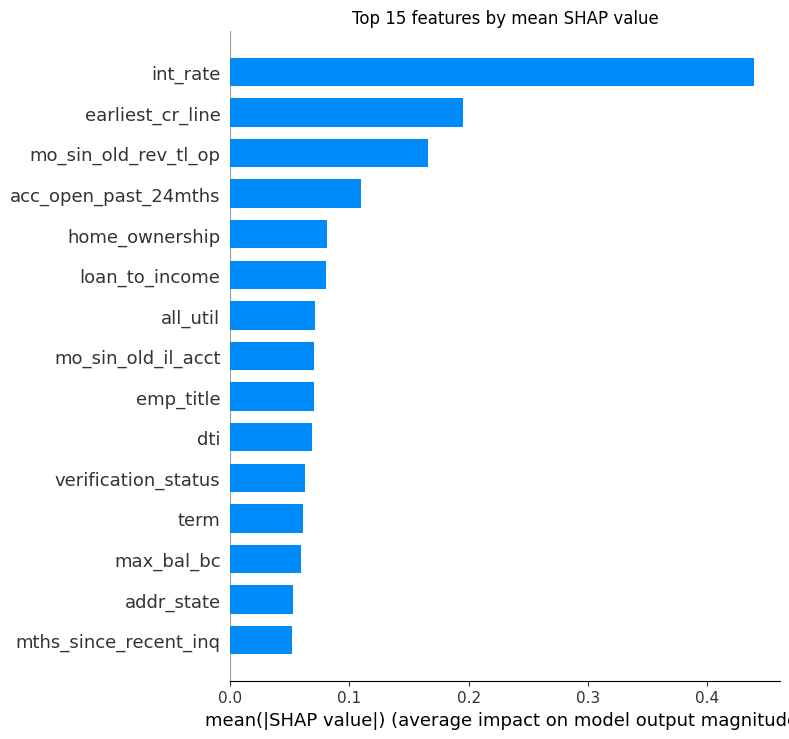

Saved shap_bar.png


In [24]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    max_display = 15,
    show=False
)
plt.title("Top 15 features by mean SHAP value")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved shap_bar.png")

Beeswarm Plot

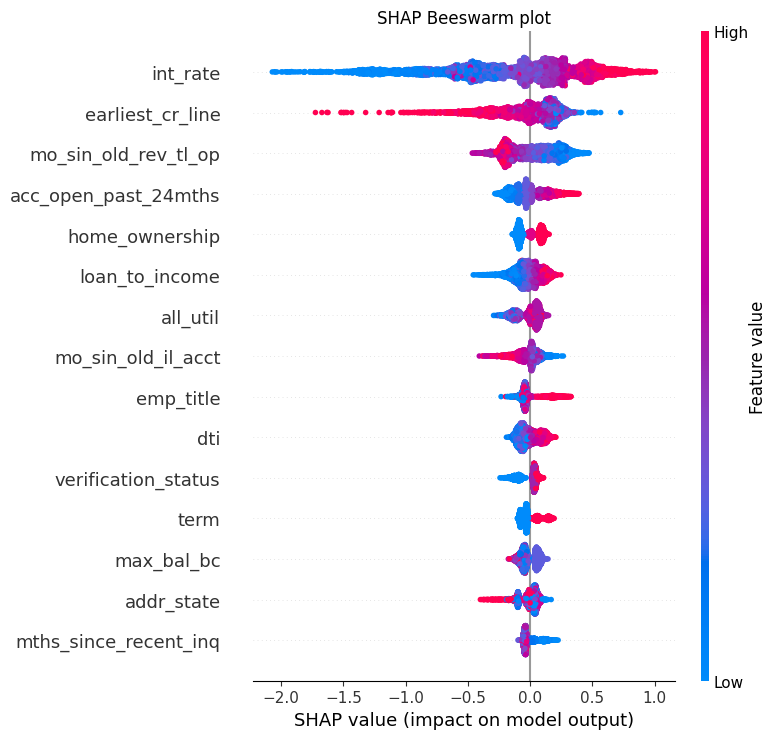

Saved...


In [25]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    max_display = 15,
    show = False
)
plt.title("SHAP Beeswarm plot")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches = 'tight')
plt.show()
print("Saved...")

WaterFall Plot


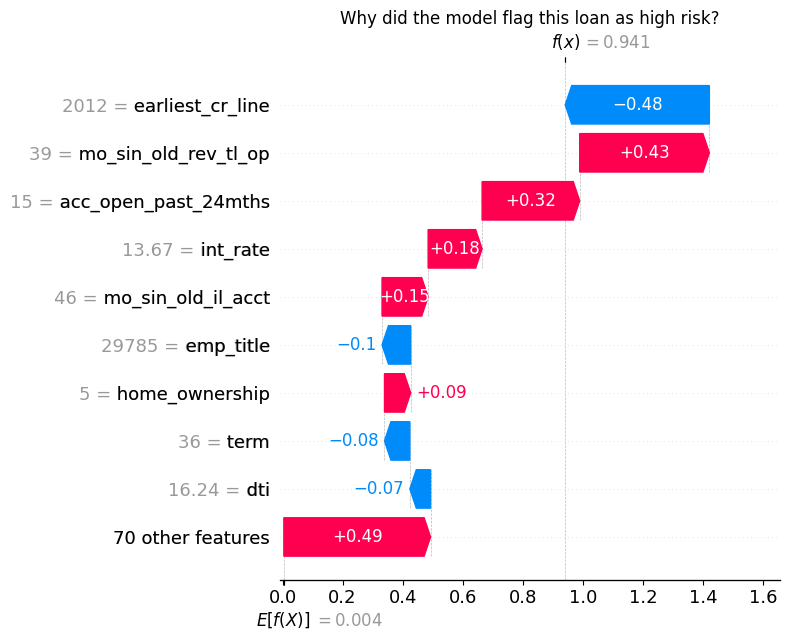

Saved shap_waterfall.png


In [26]:
# Explain a single high-risk prediction
# Find a loan your model predicted as high default risk
high_risk_idx = (y_prob[X_test.index.get_indexer(X_sample.index)] > 0.7)
high_risk_sample = X_sample[high_risk_idx].iloc[0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_risk_idx][0],
        base_values=explainer.expected_value,
        data=high_risk_sample,
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title("Why did the model flag this loan as high risk?")
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved shap_waterfall.png")

Dependence Plot

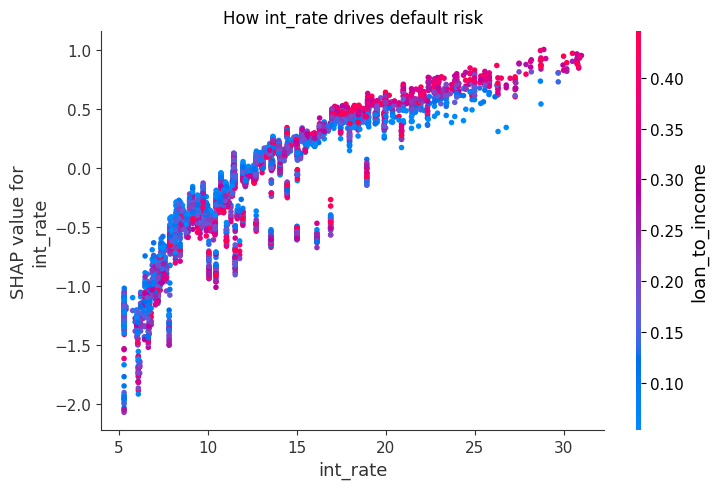

Saved shap_dependence_intrate.png


In [27]:
shap.dependence_plot(
    "int_rate",
    shap_values,
    X_sample,
    show=False
)
plt.title("How int_rate drives default risk")
plt.tight_layout()
plt.savefig("shap_dependence_intrate.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved shap_dependence_intrate.png")

In [28]:
import pickle
import os

with open('model_final.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

size = os.path.getsize('model_final.pkl') / 1024
print(f"Model saved! Size: {size:.1f} KB")

Model saved! Size: 4652.8 KB
